In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW

import warnings
warnings.filterwarnings("ignore")

# Устройство для обучения
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)

# Фиксация random seed для воспроизводимости
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Используемое устройство: cuda


In [2]:
train_path = "train.csv"
test_path = "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

train_df = train_df.rename(columns={
    "Class Index": "label",
    "Title": "title",
    "Description": "description"
})

test_df = test_df.rename(columns={
    "Class Index": "label",
    "Title": "title",
    "Description": "description"
})

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Train shape: (120000, 3)
Test shape: (7600, 3)


,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


,label,title,description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [3]:
train_df["text"] = train_df["title"].astype(str) + " " + train_df["description"].astype(str)
test_df["text"] = test_df["title"].astype(str) + " " + test_df["description"].astype(str)

train_df["label"] = train_df["label"].astype(int) - 1
test_df["label"] = test_df["label"].astype(int) - 1

label_names = ["World", "Sports", "Business", "Sci/Tech"]
num_classes = len(label_names)

print("Классы:", label_names)
print("Количество классов:", num_classes)

print("\nРаспределение классов в train:")
display(train_df["label"].value_counts().sort_index())

print("\nРаспределение классов в test:")
display(test_df["label"].value_counts().sort_index())

print("\nПример подготовленных данных:")
display(train_df[["text", "label"]].head())

Классы: ['World', 'Sports', 'Business', 'Sci/Tech']
Количество классов: 4

Распределение классов в train:


label
0    30000
1    30000
2    30000
3    30000
Name: count, dtype: int64


Распределение классов в test:


label
0    1900
1    1900
2    1900
3    1900
Name: count, dtype: int64


Пример подготовленных данных:


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [4]:
TRAIN_LIMIT = 60000
TEST_LIMIT = 7600

def balanced_sample(df, limit, label_col="label", seed=42):
    classes = sorted(df[label_col].unique())
    per_class = limit // len(classes)

    sampled_parts = []

    for cls in classes:
        part = df[df[label_col] == cls].sample(
            n=per_class,
            random_state=seed
        )
        sampled_parts.append(part)

    result = pd.concat(sampled_parts)
    result = result.sample(frac=1, random_state=seed).reset_index(drop=True)

    return result

train_df = balanced_sample(train_df, TRAIN_LIMIT, label_col="label", seed=SEED)

test_df = test_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

if TEST_LIMIT is not None:
    test_df = test_df.iloc[:TEST_LIMIT].reset_index(drop=True)

print("Размер train после ограничения:", train_df.shape)
print("Размер test после ограничения:", test_df.shape)

print("\nРаспределение классов в train:")
display(train_df["label"].value_counts().sort_index())

print("\nРаспределение классов в test:")
display(test_df["label"].value_counts().sort_index())

Размер train после ограничения: (60000, 4)
Размер test после ограничения: (7600, 4)

Распределение классов в train:


label
0    15000
1    15000
2    15000
3    15000
Name: count, dtype: int64


Распределение классов в test:


label
0    1900
1    1900
2    1900
3    1900
Name: count, dtype: int64

In [5]:
model_checkpoint = "albert-base-v2"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

MAX_LEN = 64

BATCH_SIZE = 16

class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = NewsDataset(
    train_df["text"].tolist(),
    train_df["label"].tolist(),
    tokenizer,
    max_len=MAX_LEN
)

test_dataset = NewsDataset(
    test_df["text"].tolist(),
    test_df["label"].tolist(),
    tokenizer,
    max_len=MAX_LEN
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Токенизатор ALBERT и DataLoader успешно созданы")

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Токенизатор ALBERT и DataLoader успешно созданы


In [6]:
batch = next(iter(train_loader))

print("input_ids shape:", batch["input_ids"].shape)
print("attention_mask shape:", batch["attention_mask"].shape)
print("labels shape:", batch["labels"].shape)

print("\nПример label:", batch["labels"][0].item())
print("Пример токенов:")
print(tokenizer.convert_ids_to_tokens(batch["input_ids"][0][:20]))

input_ids shape: torch.Size([16, 64])
attention_mask shape: torch.Size([16, 64])
labels shape: torch.Size([16])

Пример label: 3
Пример токенов:
['[CLS]', '▁ban', '▁hits', '▁half', '-', 'life', '▁2', '▁pirates', '▁hard', '▁game', '▁maker', '▁valve', '▁shut', '▁down', '▁the', '▁online', '▁accounts', '▁of', '▁the', '▁players']


In [7]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()

        assert d_model % num_heads == 0, "d_model должен делиться на num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None):
        batch_size, seq_len, _ = x.size()

        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)

        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1))
        scores = scores / (self.head_dim ** 0.5)

        if attention_mask is not None:
            # attention_mask: [B, T] -> [B, 1, 1, T]
            mask = attention_mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        out = torch.matmul(attn_weights, V)

        out = out.transpose(1, 2).contiguous()
        out = out.view(batch_size, seq_len, self.d_model)

        out = self.out_proj(out)

        return out


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        self.self_attn = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None):
        # Self-attention + residual connection
        attn_out = self.self_attn(self.norm1(x), attention_mask)
        x = x + self.dropout(attn_out)

        # Feed-forward + residual connection
        ff_out = self.feed_forward(self.norm2(x))
        x = x + self.dropout(ff_out)

        return x


class TokenAndPositionEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_len):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_len, d_model)

    def forward(self, input_ids):
        batch_size, seq_len = input_ids.size()

        positions = torch.arange(seq_len, device=input_ids.device)
        positions = positions.unsqueeze(0).expand(batch_size, seq_len)

        token_emb = self.token_embedding(input_ids)
        pos_emb = self.position_embedding(positions)

        return token_emb + pos_emb


class EncoderOnlyTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model,
        num_heads,
        d_ff,
        num_layers,
        num_classes,
        max_len,
        dropout=0.1
    ):
        super().__init__()

        self.embedding = TokenAndPositionEmbedding(vocab_size, d_model, max_len)
        self.dropout = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x, attention_mask)

        x = self.norm(x)

        # Masked mean pooling: усредняем только настоящие токены, а не padding
        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1)
            x = x * mask
            pooled = x.sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        else:
            pooled = x.mean(dim=1)

        logits = self.classifier(pooled)

        return logits

In [8]:
vocab_size = tokenizer.vocab_size

D_MODEL = 128
NUM_HEADS = 4
D_FF = 256
NUM_LAYERS = 2
DROPOUT = 0.1

custom_model = EncoderOnlyTransformer(
    vocab_size=vocab_size,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    num_layers=NUM_LAYERS,
    num_classes=num_classes,
    max_len=MAX_LEN,
    dropout=DROPOUT
).to(device)

criterion = nn.CrossEntropyLoss()
custom_optimizer = AdamW(custom_model.parameters(), lr=1e-4)

total_params = sum(p.numel() for p in custom_model.parameters())
trainable_params = sum(p.numel() for p in custom_model.parameters() if p.requires_grad)

print(custom_model)
print(f"\nВсего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")

EncoderOnlyTransformer(
  (embedding): TokenAndPositionEmbedding(
    (token_embedding): Embedding(30000, 128)
    (position_embedding): Embedding(64, 128)
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (layers): ModuleList(
    (0-1): 2 x EncoderLayer(
      (self_attn): MultiHeadSelfAttention(
        (q_proj): Linear(in_features=128, out_features=128, bias=True)
        (k_proj): Linear(in_features=128, out_features=128, bias=True)
        (v_proj): Linear(in_features=128, out_features=128, bias=True)
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feed_forward): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=256, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=256, out_features=128, bias=True)
        )
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      

In [9]:
from tqdm.auto import tqdm
import time

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(dataloader, desc="Обучение", leave=False)

    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        progress_bar.set_postfix({"loss": loss.item()})

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, accuracy, f1


def evaluate_model(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(dataloader, desc="Оценка", leave=False)

    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, accuracy, f1, all_labels, all_preds

In [10]:
CUSTOM_EPOCHS = 5

custom_history = {
    "train_loss": [],
    "train_accuracy": [],
    "train_f1": [],
    "test_loss": [],
    "test_accuracy": [],
    "test_f1": []
}

start_time = time.time()

for epoch in range(CUSTOM_EPOCHS):
    print(f"\nЭпоха {epoch + 1}/{CUSTOM_EPOCHS}")

    train_loss, train_acc, train_f1 = train_one_epoch(
        custom_model,
        train_loader,
        custom_optimizer,
        criterion,
        device
    )

    test_loss, test_acc, test_f1, _, _ = evaluate_model(
        custom_model,
        test_loader,
        criterion,
        device
    )

    custom_history["train_loss"].append(train_loss)
    custom_history["train_accuracy"].append(train_acc)
    custom_history["train_f1"].append(train_f1)
    custom_history["test_loss"].append(test_loss)
    custom_history["test_accuracy"].append(test_acc)
    custom_history["test_f1"].append(test_f1)

    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Test  Loss: {test_loss:.4f} | Test  Accuracy: {test_acc:.4f} | Test  F1: {test_f1:.4f}")

end_time = time.time()
custom_training_time = end_time - start_time

print(f"\nВремя обучения собственной модели: {custom_training_time / 60:.2f} минут")


Эпоха 1/5


Обучение:   0%|          | 0/3750 [00:00<?, ?it/s]

Оценка:   0%|          | 0/475 [00:00<?, ?it/s]

Train Loss: 0.9231 | Train Accuracy: 0.6173 | Train F1: 0.6155
Test  Loss: 0.6493 | Test  Accuracy: 0.7576 | Test  F1: 0.7560

Эпоха 2/5


Обучение:   0%|          | 0/3750 [00:00<?, ?it/s]

...

Оценка:   0%|          | 0/475 [00:00<?, ?it/s]

Train Loss: 0.4098 | Train Accuracy: 0.8544 | Train F1: 0.8541
Test  Loss: 0.4098 | Test  Accuracy: 0.8559 | Test  F1: 0.8557

Эпоха 5/5


Обучение:   0%|          | 0/3750 [00:00<?, ?it/s]

Оценка:   0%|          | 0/475 [00:00<?, ?it/s]

Train Loss: 0.3702 | Train Accuracy: 0.8696 | Train F1: 0.8693
Test  Loss: 0.3982 | Test  Accuracy: 0.8608 | Test  F1: 0.8602

Время обучения собственной модели: 7.04 минут


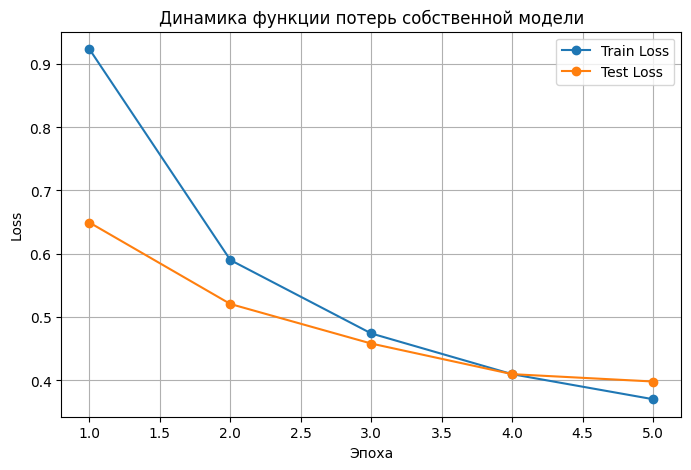

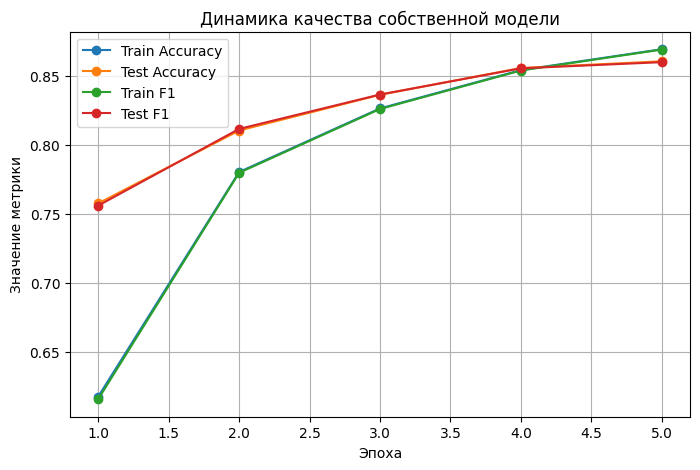

In [11]:
epochs_range = range(1, CUSTOM_EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, custom_history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs_range, custom_history["test_loss"], marker="o", label="Test Loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Динамика функции потерь собственной модели")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, custom_history["train_accuracy"], marker="o", label="Train Accuracy")
plt.plot(epochs_range, custom_history["test_accuracy"], marker="o", label="Test Accuracy")
plt.plot(epochs_range, custom_history["train_f1"], marker="o", label="Train F1")
plt.plot(epochs_range, custom_history["test_f1"], marker="o", label="Test F1")
plt.xlabel("Эпоха")
plt.ylabel("Значение метрики")
plt.title("Динамика качества собственной модели")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
custom_test_loss, custom_test_accuracy, custom_test_f1, custom_true_labels, custom_pred_labels = evaluate_model(
    custom_model,
    test_loader,
    criterion,
    device
)

print("Итоговые результаты собственной модели:")
print(f"Loss: {custom_test_loss:.4f}")
print(f"Accuracy: {custom_test_accuracy:.4f}")
print(f"F1-score: {custom_test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    custom_true_labels,
    custom_pred_labels,
    target_names=label_names
))

Оценка:   0%|          | 0/475 [00:00<?, ?it/s]

Итоговые результаты собственной модели:
Loss: 0.3982
Accuracy: 0.8608
F1-score: 0.8602

Classification Report:
              precision    recall  f1-score   support

       World       0.86      0.88      0.87      1900
      Sports       0.92      0.94      0.93      1900
    Business       0.80      0.85      0.82      1900
    Sci/Tech       0.87      0.77      0.82      1900

    accuracy                           0.86      7600
   macro avg       0.86      0.86      0.86      7600
weighted avg       0.86      0.86      0.86      7600



In [13]:
train_path = "train.csv"
test_path = "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

train_df = train_df.rename(columns={
    "Class Index": "label",
    "Title": "title",
    "Description": "description"
})

test_df = test_df.rename(columns={
    "Class Index": "label",
    "Title": "title",
    "Description": "description"
})

# Объединяем заголовок и описание
train_df["text"] = train_df["title"].astype(str) + " " + train_df["description"].astype(str)
test_df["text"] = test_df["title"].astype(str) + " " + test_df["description"].astype(str)

# Метки 1-4 переводим в 0-3
train_df["label"] = train_df["label"].astype(int) - 1
test_df["label"] = test_df["label"].astype(int) - 1

label_names = ["World", "Sports", "Business", "Sci/Tech"]
num_classes = len(label_names)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nРаспределение классов в train:")
display(train_df["label"].value_counts().sort_index())

print("\nРаспределение классов в test:")
display(test_df["label"].value_counts().sort_index())

Train shape: (120000, 4)
Test shape: (7600, 4)

Распределение классов в train:


label
0    30000
1    30000
2    30000
3    30000
Name: count, dtype: int64


Распределение классов в test:


label
0    1900
1    1900
2    1900
3    1900
Name: count, dtype: int64

In [14]:
TRAIN_LIMIT = 120000
TEST_LIMIT = 7600

# Перемешиваем полный train
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

train_df = train_df.iloc[:TRAIN_LIMIT].reset_index(drop=True)
test_df = test_df.iloc[:TEST_LIMIT].reset_index(drop=True)

BATCH_SIZE = 32

train_dataset = NewsDataset(
    train_df["text"].tolist(),
    train_df["label"].tolist(),
    tokenizer,
    max_len=MAX_LEN
)

test_dataset = NewsDataset(
    test_df["text"].tolist(),
    test_df["label"].tolist(),
    tokenizer,
    max_len=MAX_LEN
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Размер train:", len(train_dataset))
print("Размер test:", len(test_dataset))
print("Количество батчей train:", len(train_loader))
print("Количество батчей test:", len(test_loader))

Размер train: 120000
Размер test: 7600
Количество батчей train: 3750
Количество батчей test: 238


In [15]:
custom_optimizer = AdamW(custom_model.parameters(), lr=5e-5)
ADDITIONAL_EPOCHS = 3

start_time = time.time()

for epoch in range(ADDITIONAL_EPOCHS):
    print(f"\nДополнительная эпоха {epoch + 1}/{ADDITIONAL_EPOCHS}")

    train_loss, train_acc, train_f1 = train_one_epoch(
        custom_model,
        train_loader,
        custom_optimizer,
        criterion,
        device
    )

    test_loss, test_acc, test_f1, _, _ = evaluate_model(
        custom_model,
        test_loader,
        criterion,
        device
    )

    custom_history["train_loss"].append(train_loss)
    custom_history["train_accuracy"].append(train_acc)
    custom_history["train_f1"].append(train_f1)
    custom_history["test_loss"].append(test_loss)
    custom_history["test_accuracy"].append(test_acc)
    custom_history["test_f1"].append(test_f1)

    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Test  Loss: {test_loss:.4f} | Test  Accuracy: {test_acc:.4f} | Test  F1: {test_f1:.4f}")

end_time = time.time()

print(f"\nДополнительное время обучения: {(end_time - start_time) / 60:.2f} минут")


Дополнительная эпоха 1/3


Обучение:   0%|          | 0/3750 [00:00<?, ?it/s]

Оценка:   0%|          | 0/238 [00:00<?, ?it/s]

Train Loss: 0.3557 | Train Accuracy: 0.8748 | Train F1: 0.8746
Test  Loss: 0.3549 | Test  Accuracy: 0.8764 | Test  F1: 0.8762

Дополнительная эпоха 2/3


Обучение:   0%|          | 0/3750 [00:00<?, ?it/s]

Оценка:   0%|          | 0/238 [00:00<?, ?it/s]

Train Loss: 0.3367 | Train Accuracy: 0.8820 | Train F1: 0.8818
Test  Loss: 0.3453 | Test  Accuracy: 0.8804 | Test  F1: 0.8801

Дополнительная эпоха 3/3


Обучение:   0%|          | 0/3750 [00:00<?, ?it/s]

Оценка:   0%|          | 0/238 [00:00<?, ?it/s]

Train Loss: 0.3193 | Train Accuracy: 0.8888 | Train F1: 0.8886
Test  Loss: 0.3392 | Test  Accuracy: 0.8842 | Test  F1: 0.8837

Дополнительное время обучения: 5.23 минут
